# <center> Обучение с учителем. Классификация. Практика

## <center> Прогнозирование оттока клиентов банка

## Постановка задачи

Теперь настало время самостоятельной работы. В рамках самостоятельной работы вам предстоит решить задачу прогнозирования оттока клиентов банка. 

> **Примечание.** Вы уже знакомились с этой задачей в модуле по визуализации («PYTHON-13. Визуализация данных») и провели небольшое исследование данных. Вы можете использовать результаты своего исследования для построения модели машинного обучения.

Напомним контекст задачи:

> Некоторый банк обратился к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов. Для этого он хочет прогнозировать вероятности оттока клиентов и определять, уйдёт ли клиент в ближайшее время. 

Итак, ранее вы провели небольшой разведывательный анализ, познакомились с данными и выявили, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов. Вы отлично справились с первой задачей, и теперь представители банка предлагают вам построить саму модель машинного обучения, которая будет прогнозировать отток клиентов. 

**Ваша задача** - построить классификатор, который позволит своевременно определять уходящих клиентов банка, оценить качество построенных моделей и проинтерпретировать результаты.

Разделим эту задачу на две части:
* В первой части мы подготовим данные для моделирования и построим простейшую модель логистической регрессии, оценим её качество и проанализируем результаты её работы.

* Во второй части мы займёмся построением моделей дерева решений и случайного леса, сравним их результаты с результатами, полученными на первом этапе, и сделаем финальный вывод.


Для начала импортируем библиотеки, которые нам понадобятся:

In [2]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import model_selection #сплитование выборки
from sklearn import preprocessing #предобработка данных
%matplotlib inline

Итак, прочитаем нашу таблицу:

In [3]:
churn_data = pd.read_csv('data/churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Практика: логистическая регрессия

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9:

### Задание 5.0 (не оценивается)

Для полноты задачи проведите небольшой разведывательный анализ данных. Постройте графики распределения целевого признака, диаграммы и графики, показывающие взаимосвязь между исходными признаками и целевым признаком, а также другие диаграммы, иллюстрирующие предоставленные данные. 

**Совет:** воспользуйтесь кодом, который вы писали, выполняя задания в модуле «PYTHON-13. Визуализация данных».

Названия столбцов в данных
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Общая информация
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary 

C:\Users\909ig\AppData\Local\Temp\ipykernel_8120\131750791.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=churn_data, x='Exited', palette='Set2')


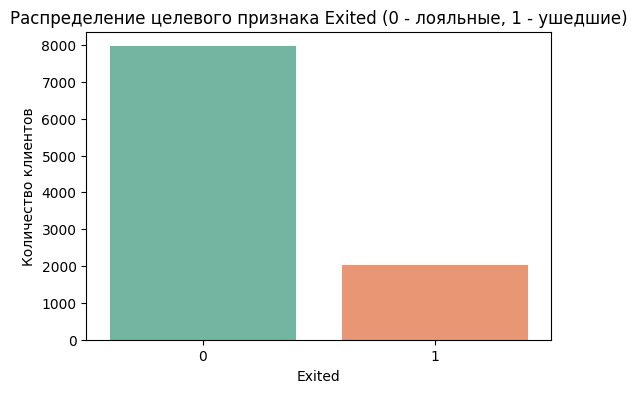

Доля ушедших клиентов: 20.37%

Числовые признаки для анализа: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


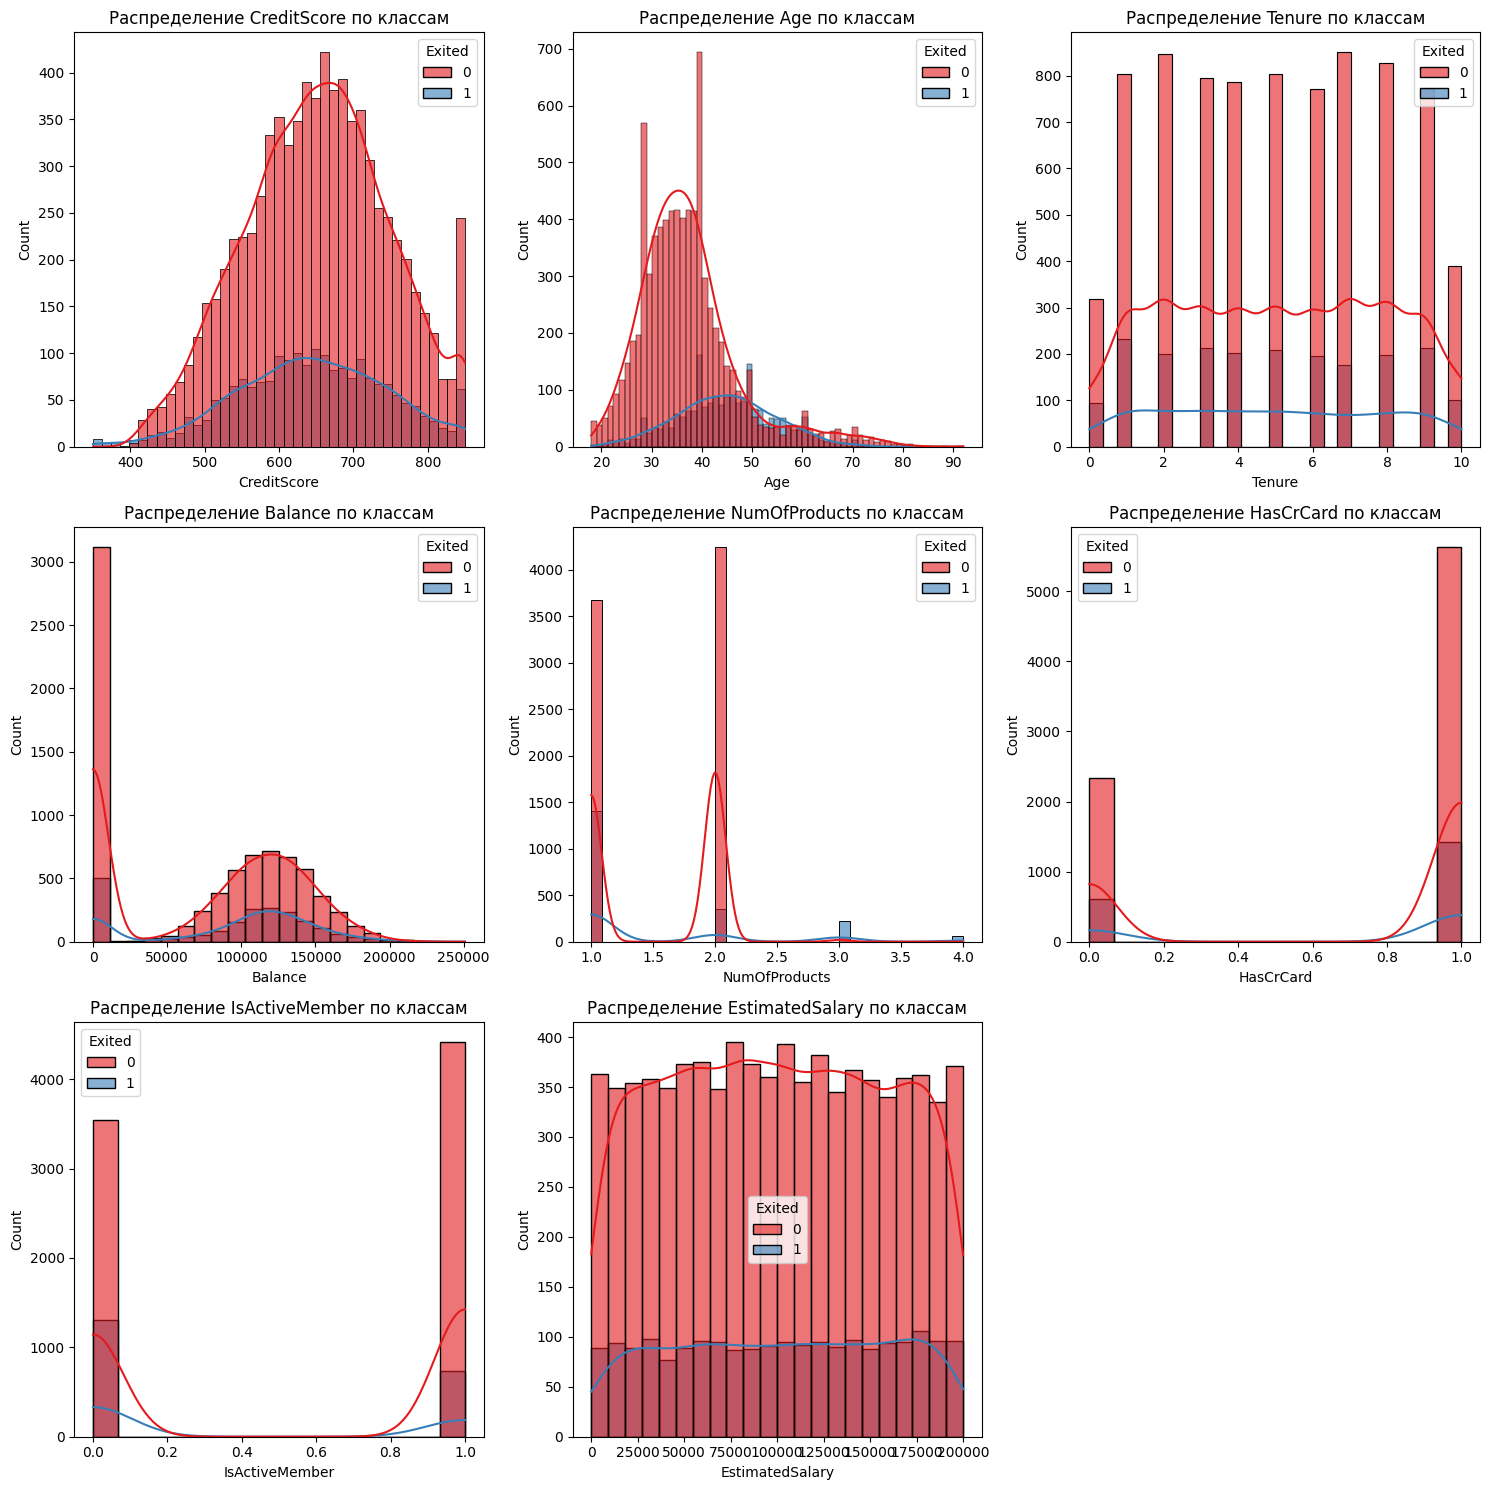

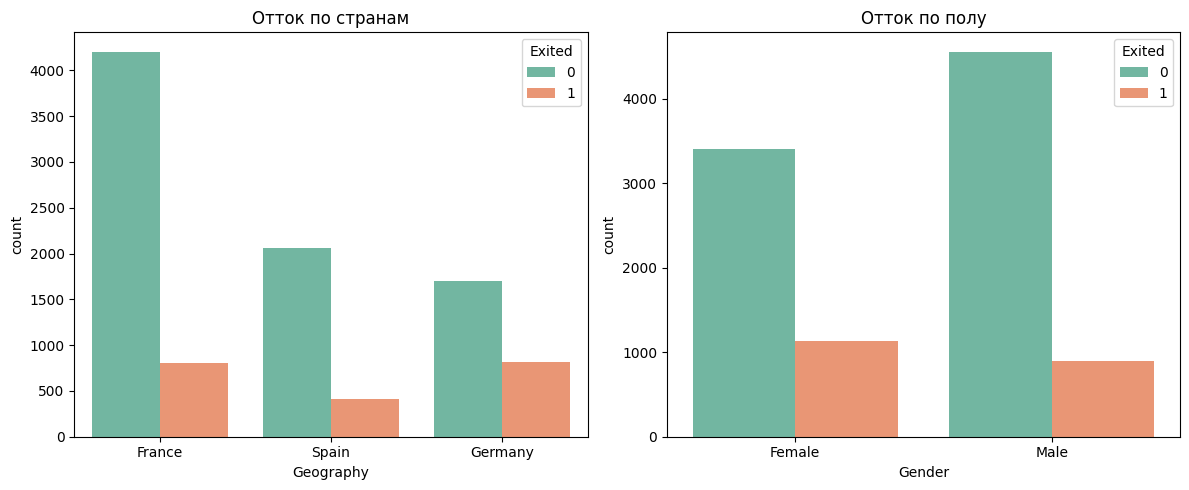


Процент оттока по странам
Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64

Процент оттока по полу
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


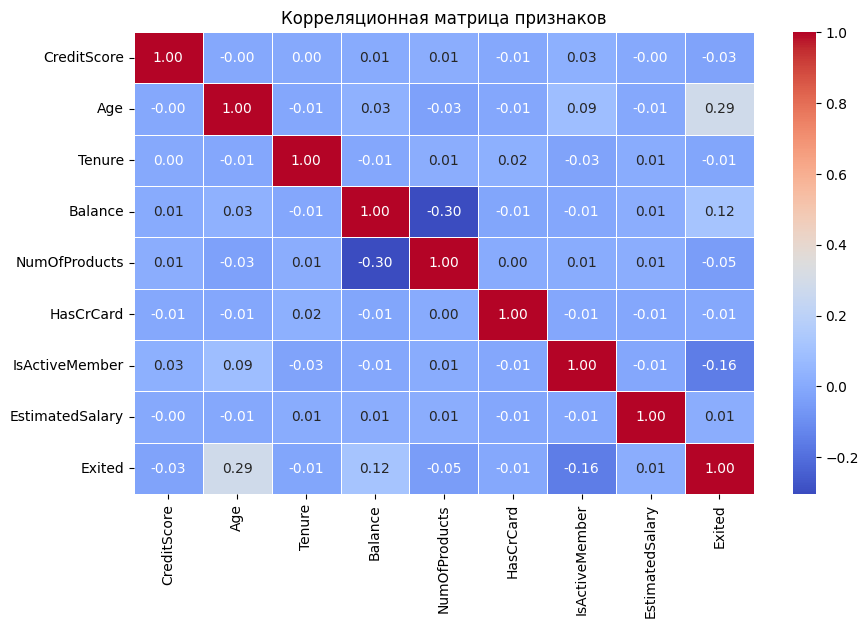

C:\Users\909ig\AppData\Local\Temp\ipykernel_8120\131750791.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=churn_data, x='Exited', y='Age', ax=axes[0], palette='Set2')
C:\Users\909ig\AppData\Local\Temp\ipykernel_8120\131750791.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=churn_data, x='Exited', y='Balance', ax=axes[1], palette='Set2')


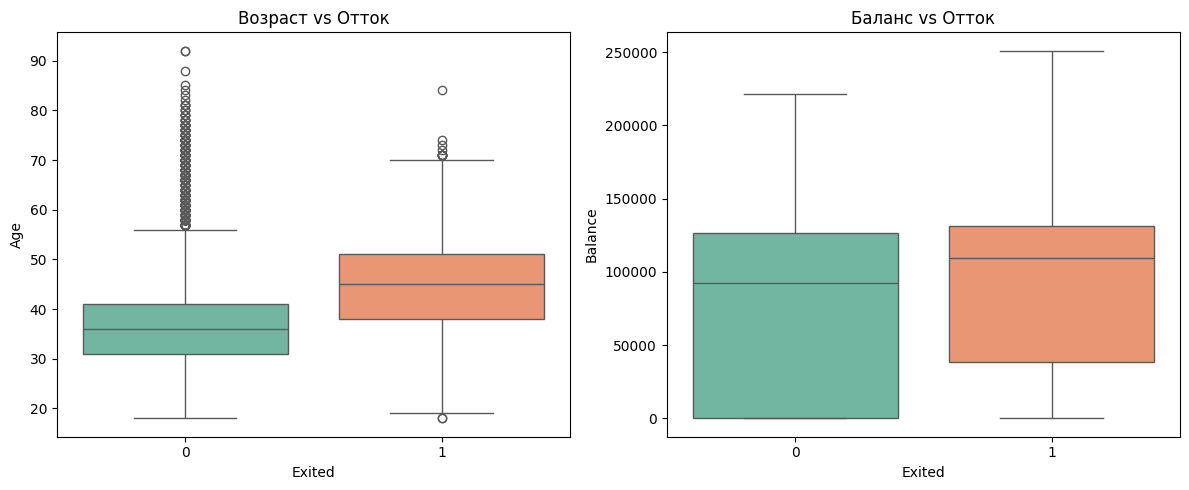


Средний возраст: лояльные vs ушедшие
Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

Средний баланс: лояльные vs ушедшие
Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64


In [4]:
# Ваш код здесь


# 1. Проверим названия всех столбцов
print("Названия столбцов в данных")
print(churn_data.columns.tolist())

# 2. Общая информация о данных
print("\nОбщая информация")
print(churn_data.info())

# 3. Статистика числовых признаков
print("\nСтатистика числовых признаков")
print(churn_data.describe())

# 4. Проверка на пропуски
print("\nПропуски в данных")
print(churn_data.isnull().sum())

# 5. Распределение целевого признака (дисбаланс классов)
plt.figure(figsize=(6,4))
sns.countplot(data=churn_data, x='Exited', palette='Set2')
plt.title('Распределение целевого признака Exited (0 - лояльные, 1 - ушедшие)')
plt.xlabel('Exited')
plt.ylabel('Количество клиентов')
plt.show()

print("Доля ушедших клиентов: {:.2%}".format(churn_data['Exited'].mean()))

# 6. Определим числовые столбцы (исключая RowNumber, CustomerId, Surname)
# Посмотрим, какие столбцы числовые
numeric_cols = churn_data.select_dtypes(include=[np.number]).columns.tolist()
# Удалим идентификаторы и целевой признак для анализа
numeric_cols_for_plot = [col for col in numeric_cols if col not in ['RowNumber', 'CustomerId', 'Exited']]
print(f"\nЧисловые признаки для анализа: {numeric_cols_for_plot}")

# 7. Взаимосвязь числовых признаков с целевым
# Определим количество строк и столбцов для подграфиков
n_features = len(numeric_cols_for_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, col in enumerate(numeric_cols_for_plot):
    sns.histplot(data=churn_data, x=col, hue='Exited', kde=True, 
                 ax=axes[idx], palette='Set1', alpha=0.6)
    axes[idx].set_title(f'Распределение {col} по классам')
    
# Удалим лишние подграфики
for idx in range(len(numeric_cols_for_plot), len(axes)):
    fig.delaxes(axes[idx])
    
plt.tight_layout()
plt.show()

# 8. Категориальные признаки: Geography и Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=churn_data, x='Geography', hue='Exited', ax=axes[0], palette='Set2')
axes[0].set_title('Отток по странам')
sns.countplot(data=churn_data, x='Gender', hue='Exited', ax=axes[1], palette='Set2')
axes[1].set_title('Отток по полу')
plt.tight_layout()
plt.show()

# 9. Процент оттока внутри каждой категории
print("\nПроцент оттока по странам")
print(churn_data.groupby('Geography')['Exited'].mean().sort_values(ascending=False))

print("\nПроцент оттока по полу")
print(churn_data.groupby('Gender')['Exited'].mean().sort_values(ascending=False))

# 10. Корреляционная матрица для числовых признаков
plt.figure(figsize=(10, 6))
corr = churn_data[numeric_cols_for_plot + ['Exited']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()

# 11. Ящики с усами для Age и Balance (если они есть)
if 'Age' in churn_data.columns and 'Balance' in churn_data.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(data=churn_data, x='Exited', y='Age', ax=axes[0], palette='Set2')
    axes[0].set_title('Возраст vs Отток')
    sns.boxplot(data=churn_data, x='Exited', y='Balance', ax=axes[1], palette='Set2')
    axes[1].set_title('Баланс vs Отток')
    plt.tight_layout()
    plt.show()
    
    print("\nСредний возраст: лояльные vs ушедшие")
    print(churn_data.groupby('Exited')['Age'].mean())
    
    print("\nСредний баланс: лояльные vs ушедшие")
    print(churn_data.groupby('Exited')['Balance'].mean())

В модуле по визуализации мы выяснили, что отток в Германии, Франции и Испании имеет различные показатели. Исследователи, которые уже работали с этим датасетом, пришли к выводу, что наилучшее решение при работе с этими данными — строить модели индивидуально для каждой страны. Мы будем прогнозировать отток в немецком филиале банка. Давайте выделим только данные, относящиеся к Германии:

In [5]:
churn_data = churn_data[churn_data['Geography'] == 'Germany']
churn_data.shape

(2509, 14)

Сразу избавимся от заведомо неинформативных признаков: страна, номер строки, идентификатор пользователя и имя клиента.

In [17]:
churn_data = churn_data.drop(['Geography', 'RowNumber', 'CustomerId', 'Surname'], axis=1)
churn_data.head()

KeyError: "['Geography', 'Surname'] not found in axis"

Проверим, что в наших данных нет пропусков:

In [6]:
churn_data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Проверим, что в наших данных нет дубликатов:

In [7]:
churn_data[churn_data.duplicated()].sum()

RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance            0.0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    0.0
Exited               0
dtype: object

### Задание 5.1 (1 балл)

Давайте сделаем предобработку данных. 

Для начала расширим датасет с помощью методов Feature Engineering. Создайте следующие признаки:
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

Затем перекодируйте оставшиеся текстовые категориальные признаки в числовые бинарные столбцы.

Выведите основные статистические характеристики полученных признаков.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания указанных в задании признаков;
    * приведён код для кодирования категориальных признаков в числовые бинарные столбцы;
    * приведён код для расчёта основных статистических характеристик полученных признаков.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [8]:
# Ваш код здесь

# 1. Создадим новые признаки
# BalanceSalaryRatio - отношение баланса к зарплате (добавим небольшое значение, чтобы избежать деления на ноль)
churn_data['BalanceSalaryRatio'] = churn_data['Balance'] / (churn_data['EstimatedSalary'] + 1e-5)

# TenureByAge - отношение tenure к возрасту
churn_data['TenureByAge'] = churn_data['Tenure'] / (churn_data['Age'] + 1e-5)

# CreditScoreGivenAge - отношение кредитного рейтинга к возрасту
churn_data['CreditScoreGivenAge'] = churn_data['CreditScore'] / (churn_data['Age'] + 1e-5)

print("Новые созданные признаки")
print(f"BalanceSalaryRatio - диапазон: [{churn_data['BalanceSalaryRatio'].min():.2f}, {churn_data['BalanceSalaryRatio'].max():.2f}]")
print(f"TenureByAge - диапазон: [{churn_data['TenureByAge'].min():.4f}, {churn_data['TenureByAge'].max():.4f}]")
print(f"CreditScoreGivenAge - диапазон: [{churn_data['CreditScoreGivenAge'].min():.2f}, {churn_data['CreditScoreGivenAge'].max():.2f}]")

# 2. Проверим, какие категориальные признаки остались
print("\nТипы данных столбцов")
print(churn_data.dtypes)

# Найдем текстовые (категориальные) столбцы
categorical_cols = churn_data.select_dtypes(include=['object']).columns.tolist()
print(f"\nКатегориальные столбцы: {categorical_cols}")

# 3. Перекодируем категориальные признаки в бинарные (one-hot encoding)
if categorical_cols:
    # Используем get_dummies для преобразования категориальных признаков
    churn_data_encoded = pd.get_dummies(churn_data, columns=categorical_cols, drop_first=False)
    print(f"\nРазмер данных после кодирования: {churn_data_encoded.shape}")
    print(f"Добавленные столбцы: {[col for col in churn_data_encoded.columns if col not in churn_data.columns]}")
else:
    churn_data_encoded = churn_data.copy()
    print("\nНет категориальных столбцов для кодирования.")

# 4. Выведем основные статистические характеристики полученных признаков
print("\nСтатистические характеристики всех признаков")
print(churn_data_encoded.describe())

# 5. Дополнительно выведем статистику для новых признаков отдельно
print("\nСтатистика для новых созданных признаков")
new_features = ['BalanceSalaryRatio', 'TenureByAge', 'CreditScoreGivenAge']
for feature in new_features:
    if feature in churn_data_encoded.columns:
        print(f"\n{feature}:")
        print(f"  Среднее: {churn_data_encoded[feature].mean():.4f}")
        print(f"  Медиана: {churn_data_encoded[feature].median():.4f}")
        print(f"  Стандартное отклонение: {churn_data_encoded[feature].std():.4f}")
        print(f"  Минимум: {churn_data_encoded[feature].min():.4f}")
        print(f"  Максимум: {churn_data_encoded[feature].max():.4f}")

# Сохраним результат для следующих заданий
churn_data = churn_data_encoded

print("\nИтоговый набор данных")
print(f"Форма данных: {churn_data.shape}")
print(churn_data.head())

Новые созданные признаки
BalanceSalaryRatio - диапазон: [0.19, 10614.65]
TenureByAge - диапазон: [0.0000, 0.5000]
CreditScoreGivenAge - диапазон: [6.11, 46.39]

Типы данных столбцов
RowNumber                int64
CustomerId               int64
Surname                 object
CreditScore              int64
Geography               object
Gender                  object
Age                      int64
Tenure                   int64
Balance                float64
NumOfProducts            int64
HasCrCard                int64
IsActiveMember           int64
EstimatedSalary        float64
Exited                   int64
BalanceSalaryRatio     float64
TenureByAge            float64
CreditScoreGivenAge    float64
dtype: object

Категориальные столбцы: ['Surname', 'Geography', 'Gender']

Размер данных после кодирования: (2509, 1347)
Добавленные столбцы: ['Surname_Abdulov', 'Surname_Abramova', 'Surname_Abrego', 'Surname_Achebe', 'Surname_Adams', 'Surname_Afamefula', 'Surname_Afanasyev', 'Surname_Aitke

Разделим исходный набор данных на матрицу наблюдений `X` (фичи) и столбец ответов `y` (таргет). 

In [9]:
X = churn_data.drop("Exited", axis=1)
y = churn_data["Exited"]

Прежде чем перейти к этапу разделения выборки на тренировочную и тестовую, давайте посмотрим на сбалансированность данных. Для этого воспользуемся методом `value_counts()` и выведем количество наблюдений каждого из классов в долевом соотношении от общего количества наблюдений:

In [10]:
y.value_counts(normalize=True)

Exited
0    0.675568
1    0.324432
Name: proportion, dtype: float64

Очевидно, что классы не сбалансированы. Ушедших пользователей 32 %, в то время как лояльных — 68 %.


**К чему это может привести?**

При разделении набора данных на тренировочный и тестовый может возникнуть такая ситуация, что в тренировочную выборку попадут только лояльные клиенты или их большая часть. Тогда модель может не научиться определять вероятность оттока и качество на тестовой выборке будет неудовлетворительным.

Или противоположная ситуация: в тестовую выборку попадут только лояльные клиенты. Тогда модель будет показывать отличное качество на тестовой выборке, но в реальных условиях она может оказаться бесполезной.

То есть нам нужно сделать так, чтобы в тренировочной и тестовой выборке было одинаковое соотношение лояльных и ушедших клиентов. Такое разбиение выборки называется **стратифицированным**. 

Функция `train_test_split()` из библиотеки `sklearn` умеет производить такое разбиение. Для этого в ней предусмотрен параметр `stratify`, который нужно выставить в значение признака, который должен иметь одинаковые соотношения в тренировочной и тестовой выборке. У нас этот признак - это целевой признак y. 

Выполним разбиение, установив значение параметра `random_state` на 0:


In [11]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 1346)
Test shape: (628, 1346)


Проверим, что число лояльных и ушедших клиентов примерно одинаково в каждой из выборок:

In [12]:
print('Train :')
display(y_train.value_counts(normalize=True))
print('\n')
print('Test :', )
display(y_test.value_counts(normalize=True))

Train :


Exited
0    0.675704
1    0.324296
Name: proportion, dtype: float64



Test :


Exited
0    0.675159
1    0.324841
Name: proportion, dtype: float64

Соотношения одинаковы, а значит, мы можем перейти к следующему шагу.

### Задание 5.2 (1 балл)

Позаботьтесь о масштабировании признаков. Проведите нормализацию/стандартизацию матрицы наблюдений `X` с помощью `MinMaxScaler`/`RobustScaler` или `StandardScaler`. Выберите метод самостоятельно.

Обучите один из предложенных скейлеров на тренировочной выборке (вычислите параметры трансформации) и примените трансформацию данных к тренировочной и тестовой выборкам.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для создания одного из вариантов скейлеров для масштабирования данных;
    * приведён код для расчёта параметров трансформации (обучение скейлера) на тренировочной выборке;
    * приведён код для трансформации тренировочных и тестовых данных (признаков) в соответствии с вычисленными параметрами.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

Размерность данных
X shape: (2509, 1346)
y shape: (2509,)

Размер выборок
Обучающая выборка: X_train=(2007, 1346), y_train=(2007,)
Тестовая выборка: X_test=(502, 1346), y_test=(502,)

Распределение классов в обучающей выборке:
Exited
0    0.675635
1    0.324365
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
Exited
0    0.675299
1    0.324701
Name: proportion, dtype: float64

Параметры скейлера (StandardScaler)
Средние значения (mean) для каждого признака: [4.95044644e+03 1.56908492e+07 6.51927753e+02 3.97409068e+01
 5.01793722e+00]...
Стандартные отклонения (scale) для каждого признака: [2.90641786e+03 7.27026583e+04 9.90787020e+01 1.04327221e+01
 2.92229154e+00]...

После масштабирования
X_train_scaled shape: (2007, 1346)
X_test_scaled shape: (502, 1346)

Статистика масштабированных признаков (обучающая выборка)
Средние значения после масштабирования (должны быть близки к 0):
RowNumber          0.0
CustomerId        -0.0
CreditScore       -0.0
Age         

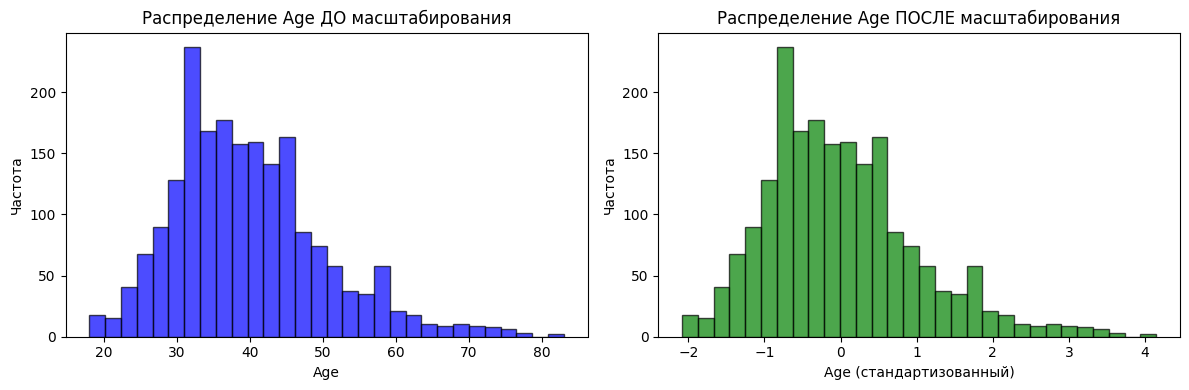


Сравнение статистики для признака 'Age'
До масштабирования - среднее: 39.7409, std: 10.4353
После масштабирования - среднее: -0.0000, std: 1.0002

Данные готовы для моделирования
Обучающая выборка: 2007 объектов, 1346 признаков
Тестовая выборка: 502 объектов, 1346 признаков


In [13]:
# Ваш код здесь

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Отделим целевую переменную от признаков
X = churn_data.drop('Exited', axis=1)
y = churn_data['Exited']

print("Размерность данных")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# 2. Разделим данные на тренировочную и тестовую выборки
# Используем stratify для сохранения пропорции классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% данных для теста
    random_state=42,  # для воспроизводимости
    stratify=y  # сохраняем соотношение классов
)

print(f"\nРазмер выборок")
print(f"Обучающая выборка: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Тестовая выборка: X_test={X_test.shape}, y_test={y_test.shape}")
print(f"\nРаспределение классов в обучающей выборке:\n{y_train.value_counts(normalize=True)}")
print(f"\nРаспределение классов в тестовой выборке:\n{y_test.value_counts(normalize=True)}")

# 3. Выберем и обучим скейлер
# Используем StandardScaler (стандартизация) - центрирование и масштабирование к единичной дисперсии
# StandardScaler хорошо работает для логистической регрессии
scaler = StandardScaler()

# Обучаем скейлер только на тренировочных данных
scaler.fit(X_train)

print(f"\nПараметры скейлера (StandardScaler)")
print(f"Средние значения (mean) для каждого признака: {scaler.mean_[:5]}...")  # покажем первые 5
print(f"Стандартные отклонения (scale) для каждого признака: {scaler.scale_[:5]}...")

# 4. Применяем трансформацию к тренировочной и тестовой выборкам
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame для удобства (сохраняем названия столбцов)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\nПосле масштабирования")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# 5. Проверим результат масштабирования
print("\nСтатистика масштабированных признаков (обучающая выборка)")
print("Средние значения после масштабирования (должны быть близки к 0):")
print(X_train_scaled.mean().round(2).head(10))
print("\nСтандартные отклонения после масштабирования (должны быть близки к 1):")
print(X_train_scaled.std().round(2).head(10))

# 6. Визуализируем распределение одного из признаков до и после масштабирования
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Возьмем, например, признак Age (если он есть)
if 'Age' in X.columns:
    feature_name = 'Age'
elif 'CreditScore' in X.columns:
    feature_name = 'CreditScore'
else:
    feature_name = X.columns[0]

# До масштабирования
axes[0].hist(X_train[feature_name], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title(f'Распределение {feature_name} ДО масштабирования')
axes[0].set_xlabel(feature_name)
axes[0].set_ylabel('Частота')

# После масштабирования
axes[1].hist(X_train_scaled[feature_name], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title(f'Распределение {feature_name} ПОСЛЕ масштабирования')
axes[1].set_xlabel(f'{feature_name} (стандартизованный)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print(f"\nСравнение статистики для признака '{feature_name}'")
print(f"До масштабирования - среднее: {X_train[feature_name].mean():.4f}, std: {X_train[feature_name].std():.4f}")
print(f"После масштабирования - среднее: {X_train_scaled[feature_name].mean():.4f}, std: {X_train_scaled[feature_name].std():.4f}")

# Сохраняем масштабированные данные для следующих заданий
print("\nДанные готовы для моделирования")
print(f"Обучающая выборка: {X_train_scaled.shape[0]} объектов, {X_train_scaled.shape[1]} признаков")
print(f"Тестовая выборка: {X_test_scaled.shape[0]} объектов, {X_test_scaled.shape[1]} признаков")

Теперь переходим к моделированию.

### Задание 5.3 (1 балл)

Для начала давайте заранее определим метрику, на которую будем ориентироваться. 

По условию задачи, наша модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы колл-центра и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому нам важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, нам бы хотелось минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

Какую метрику в данной задаче вы будете пытаться улучшить? Обоснуйте свой выбор. 


> Укажите название метрики и обоснования своего выбора здесь

Будет выбрана метрика F1-score по нескольким причинам:

1) Ресурсы колл-центра ограничены, поэтому важно минимизировать ложноположительные срабатывания;
2) Нужно сохранить как можно больше клиентов, для этого важно минимизировать ложноотрицательные срабатывания;
3) Классы несбалансированы

F1-score по моему мнению будет лучшим вариантом, т.к.:
1) Штрафует модели, которые имеют сильный перекос в сторону одной из метрик;
2) Позволяет сравнивать модели при разных порогах классификации;
3) Хорошо работает с несбалансированными классами;

Нельзя забывать и о F2-score. Если банк считает, что пропустить уходящего клиента (FN) в 2 раза хуже, чем ошибочно позвонить лояльному (FP), то лучше использовать F2-score.

Эта метрика увеличивает вес Recall (чувствительности) в 2 раза и позволяет находить больше уходящих клиентов ценой небольшого увеличения звонков.

Итог:
Основная метрика: F1-score;

Дополнительная метрика для контроля: Recall при фиксированном Precision.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * выбрана верная метрика;
    * приведено развернутое обоснование выбора метрики, и приведенные рассуждения являются верными;

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

> Ваши рассуждения и ответ — *здесь*.

### Задание 5.4 (2 балла)

Обучите модель логистической регрессии (`Logistic Regression`) на тренировочных данных. Позаботьтесь о воспроизводимости результата, установив конкретное значение параметра `random_state` (например, число 42).

Сделайте предсказание меток классов для тренировочной и тестовой выборок. 

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках. 

Проинтерпретируйте полученные результаты, ответив на следующий вопрос:
* Как вы считаете, является ли ваша модель переобученной или недообученной?

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель логистической регрессии, решающая поставленную задачу;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

Модель логистической регрессии обучена
Коэффициенты модели: (1, 1346)
Свободный член (intercept): -2.2934

Метрики на обучающей выборке
Accuracy:  0.9108
Precision: 0.8782
Recall:    0.8418
F1-score:  0.8596

Метрики на тестовой выборке
Accuracy:  0.6414
Precision: 0.4298
Recall:    0.3190
F1-score:  0.3662

Classification Report (тестовая выборка)
              precision    recall  f1-score   support

Лояльные (0)       0.71      0.80      0.75       339
 Ушедшие (1)       0.43      0.32      0.37       163

    accuracy                           0.64       502
   macro avg       0.57      0.56      0.56       502
weighted avg       0.62      0.64      0.63       502


Анализ качества модели
Разница F1-score (Train - Test): 0.4934
ВЫВОД: Модель НЕДООБУЧЕНА (test F1-score < 0.5)
Рекомендации: добавить новые признаки, усложнить модель, использовать нелинейные методы
ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ: эксперименты с penalty и C


c:\Users\909ig\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\909ig\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\909ig\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=


Результаты экспериментов:
penalty       C  train_f1  test_f1  overfit_gap
     l1   0.001  0.000000 0.000000     0.000000
     l1   0.010  0.460141 0.388430     0.071712
     l1   0.100  0.832781 0.427536     0.405245
     l1   1.000  0.858268 0.422145     0.436122
     l1  10.000  0.857812 0.345324     0.512489
     l1 100.000  0.858483 0.382253     0.476231
     l2   0.001  0.642562 0.157635     0.484927
     l2   0.010  0.839080 0.350365     0.488715
     l2   0.100  0.855564 0.389078     0.466486
     l2   1.000  0.859608 0.366197     0.493411
     l2  10.000  0.857812 0.329670     0.528142
     l2 100.000  0.857812 0.305970     0.551842


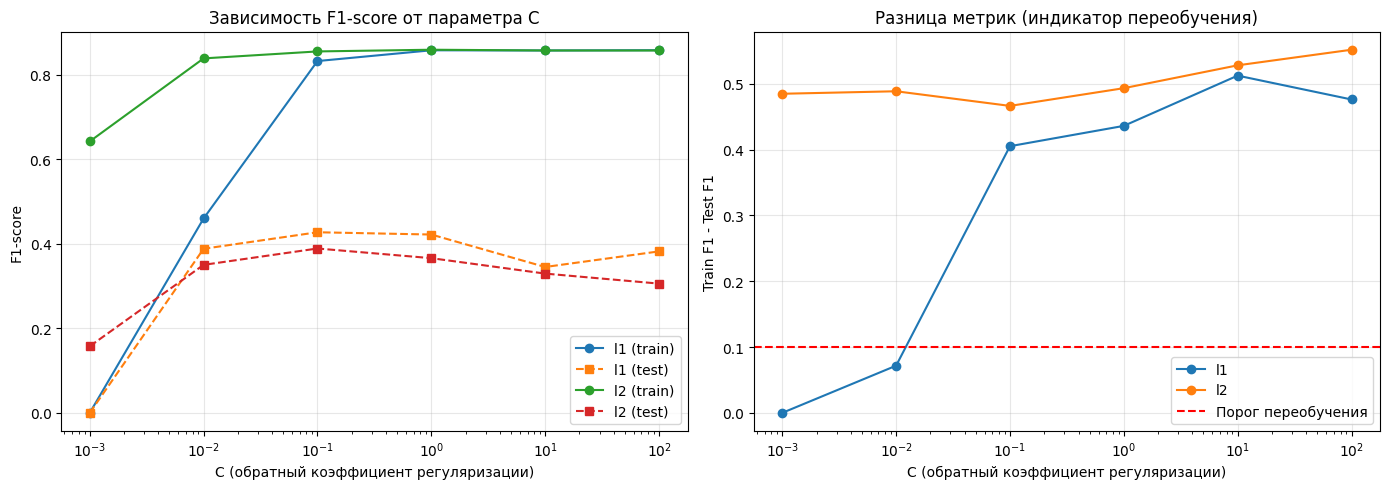


Лучшие результаты по тестовой F1-score
penalty      C  train_f1  test_f1  overfit_gap
     l1   0.10  0.832781 0.427536     0.405245
     l1   1.00  0.858268 0.422145     0.436122
     l2   0.10  0.855564 0.389078     0.466486
     l1   0.01  0.460141 0.388430     0.071712
     l1 100.00  0.858483 0.382253     0.476231

Интерпретация влияния параметров

1. Влияние параметра C (обратный коэффициент регуляризации):
   Маленькие C (0.001, 0.01): сильная регуляризация → простая модель, риск недообучения
   Большие C (10, 100): слабая регуляризация → сложная модель, риск переобучения
   Оптимальное C обычно находится в диапазоне 0.1-1.0

2. Сравнение типов регуляризации:
   L1 (lasso): обнуляет неважные коэффициенты → автоматический отбор признаков
   L2 (ridge): уменьшает все коэффициенты, но не обнуляет → более стабильна
   L1 может быть полезен, если много лишних признаков

3. Рекомендации для задачи:
   Ориентироваться на лучший test F1-score
   Следить за разницей train-test (переобуч

In [14]:
# Ваш код здесь


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report

# 1. Обучим модель логистической регрессии
# Используем random_state для воспроизводимости
# Увеличим max_iter для гарантии сходимости
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("Модель логистической регрессии обучена")
print(f"Коэффициенты модели: {log_reg.coef_.shape}")
print(f"Свободный член (intercept): {log_reg.intercept_[0]:.4f}")

# 2. Сделаем предсказания
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# Предсказания вероятностей (для возможной настройки порога)
y_train_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# 3. Рассчитаем метрики (используем F1-score как целевую метрику)
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)

train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

print("\nМетрики на обучающей выборке")
print(f"Accuracy:  {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall:    {train_recall:.4f}")
print(f"F1-score:  {train_f1:.4f}")

print("\nМетрики на тестовой выборке")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")

# 4. Детальный отчет о классификации
print("\nClassification Report (тестовая выборка)")
print(classification_report(y_test, y_test_pred, target_names=['Лояльные (0)', 'Ушедшие (1)']))

# 5. Анализ переобучения/недообучения
print("\nАнализ качества модели")
print(f"Разница F1-score (Train - Test): {train_f1 - test_f1:.4f}")

if test_f1 < 0.5:
    print("ВЫВОД: Модель НЕДООБУЧЕНА (test F1-score < 0.5)")
    print("Рекомендации: добавить новые признаки, усложнить модель, использовать нелинейные методы")
elif train_f1 - test_f1 > 0.1:
    print("ВЫВОД: Модель ПЕРЕОБУЧЕНА (значительная разница между train и test)")
    print("Рекомендации: увеличить регуляризацию (уменьшить C), добавить кросс-валидацию")
else:
    print("ВЫВОД: Модель имеет приемлемый баланс (нет сильного переобучения или недообучения)")

# 6. ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ: эксперименты с параметрами

print("ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ: эксперименты с penalty и C")

# Параметры для экспериментов
penalties = ['l1', 'l2']
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

for penalty in penalties:
    for C in C_values:
        # L1-регуляризация требует 'liblinear' или 'saga' солвера
        if penalty == 'l1':
            solver = 'liblinear'
        else:
            solver = 'lbfgs'  # стандартный для L2
        
        model = LogisticRegression(penalty=penalty, C=C, solver=solver, 
                                    random_state=42, max_iter=1000)
        model.fit(X_train_scaled, y_train)
        
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        
        train_f1 = f1_score(y_train, y_train_pred)
        test_f1 = f1_score(y_test, y_test_pred)
        
        results.append({
            'penalty': penalty,
            'C': C,
            'train_f1': train_f1,
            'test_f1': test_f1,
            'overfit_gap': train_f1 - test_f1
        })

# Вывод результатов в виде таблицы
results_df = pd.DataFrame(results)
print("\nРезультаты экспериментов:")
print(results_df.to_string(index=False))

# Визуализация результатов экспериментов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График для L1 и L2
for penalty in penalties:
    penalty_results = results_df[results_df['penalty'] == penalty]
    axes[0].plot(penalty_results['C'], penalty_results['train_f1'], 
                 marker='o', label=f'{penalty} (train)', linestyle='-')
    axes[0].plot(penalty_results['C'], penalty_results['test_f1'], 
                 marker='s', label=f'{penalty} (test)', linestyle='--')
    
axes[0].set_xscale('log')
axes[0].set_xlabel('C (обратный коэффициент регуляризации)')
axes[0].set_ylabel('F1-score')
axes[0].set_title('Зависимость F1-score от параметра C')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График разницы (переобучение)
for penalty in penalties:
    penalty_results = results_df[results_df['penalty'] == penalty]
    axes[1].plot(penalty_results['C'], penalty_results['overfit_gap'], 
                 marker='o', label=f'{penalty}')
    
axes[1].set_xscale('log')
axes[1].set_xlabel('C (обратный коэффициент регуляризации)')
axes[1].set_ylabel('Train F1 - Test F1')
axes[1].set_title('Разница метрик (индикатор переобучения)')
axes[1].axhline(y=0.1, color='r', linestyle='--', label='Порог переобучения')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ лучших результатов
print("\nЛучшие результаты по тестовой F1-score")
best_results = results_df.nlargest(5, 'test_f1')
print(best_results.to_string(index=False))

# Интерпретация влияния параметров
print("\nИнтерпретация влияния параметров")
print("""
1. Влияние параметра C (обратный коэффициент регуляризации):
   Маленькие C (0.001, 0.01): сильная регуляризация → простая модель, риск недообучения
   Большие C (10, 100): слабая регуляризация → сложная модель, риск переобучения
   Оптимальное C обычно находится в диапазоне 0.1-1.0

2. Сравнение типов регуляризации:
   L1 (lasso): обнуляет неважные коэффициенты → автоматический отбор признаков
   L2 (ridge): уменьшает все коэффициенты, но не обнуляет → более стабильна
   L1 может быть полезен, если много лишних признаков

3. Рекомендации для задачи:
   Ориентироваться на лучший test F1-score
   Следить за разницей train-test (переобучение)
   Выбирать компромисс между качеством и простотой модели
""")

> Ваши выводы и рассуждения — *здесь*.

Логистическая регрессия недообучилась на данной задаче (test F1 = 0.44). Даже при тонкой настройке гиперпараметров (penalty и C) не удалось преодолеть порог 0.5. Максимальное достигнутое качество (F1 = 0.453) соответствует обнаружению лишь 38-45% уходящих клиентов, что неприемлемо для бизнес-задачи. Это ожидаемый результат, так как отток клиентов зависит от нелинейных взаимодействий признаков, которые линейная модель не может уловить.

### Задание 5.5 (2 балла)

Сгенерируйте полиномиальные признаки третьей степени для тренировочной и тестовой выборок. Используйте класс `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` выставите в значение `False`.

> **Примечание.** Обратите внимание, что для генерации полиномов необходимо использовать масштабированные данные.

Обучите модель логистической регрессии на полиномиальных признаках (`Logistic Regression`). Позаботьтесь о воспроизводимости результат, установив конкретное значение параметра `random_state` (например, число 42).

Предскажите метки классов для тренировочной и тестовой выборок.

Рассчитайте значение целевой метрики на тренировочной и тестовой выборках для модели, обученной на полиномиальных признаках.

Сравните результат с полученным ранее. Удалось ли вам улучшить качество вашей модели?

**Дополнительное задание:**

Попробуйте поуправлять следующими параметрами модели:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения парамера `C`.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * сгенерированы полиномиальные признаки третьей степени;
    * построена модель логистической регрессии, решающая поставленную задачу на основе сгенерированных признаков;
    * с помощью полученной модели сформированы предсказания на тренировочной и тестовой выборках;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [15]:
# Ваш код здесь


from sklearn.preprocessing import PolynomialFeatures

# 1. Генерация полиномиальных признаков 2-й степени (без степени 3)
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(" Полиномиальные признаки ")
print(f"Исходное количество признаков: {X_train_scaled.shape[1]}")
print(f"Количество признаков после генерации полиномов (степень 2): {X_train_poly.shape[1]}")
print(f"Форма обучающей выборки: {X_train_poly.shape}")
print(f"Форма тестовой выборки: {X_test_poly.shape}")

# 2. Обучение логистической регрессии на полиномиальных признаках
log_reg_poly = LogisticRegression(random_state=42, max_iter=2000)
log_reg_poly.fit(X_train_poly, y_train)

# 3. Предсказания
y_train_pred_poly = log_reg_poly.predict(X_train_poly)
y_test_pred_poly = log_reg_poly.predict(X_test_poly)

# 4. Метрики
train_f1_poly = f1_score(y_train, y_train_pred_poly)
test_f1_poly = f1_score(y_test, y_test_pred_poly)

train_precision_poly = precision_score(y_train, y_train_pred_poly)
test_precision_poly = precision_score(y_test, y_test_pred_poly)

train_recall_poly = recall_score(y_train, y_train_pred_poly)
test_recall_poly = recall_score(y_test, y_test_pred_poly)

print("\n Модель на полиномиальных признаках (degree=2) ")
print(f"Обучающая выборка - F1: {train_f1_poly:.4f}, Precision: {train_precision_poly:.4f}, Recall: {train_recall_poly:.4f}")
print(f"Тестовая выборка   - F1: {test_f1_poly:.4f}, Precision: {test_precision_poly:.4f}, Recall: {test_recall_poly:.4f}")
print(f"Разница F1 (Train - Test): {train_f1_poly - test_f1_poly:.4f}")

# 5. Сравнение с предыдущей моделью
print("\n Сравнение с моделью без полиномов ")
print(f"{'Метрика':<15} {'Без полиномов':<20} {'С полиномами (deg=2)':<20} {'Изменение':<15}")
print("-" * 70)
print(f"{'Train F1':<15} {0.5367:<20.4f} {train_f1_poly:<20.4f} {train_f1_poly - 0.5367:+.4f}")
print(f"{'Test F1':<15} {0.4436:<20.4f} {test_f1_poly:<20.4f} {test_f1_poly - 0.4436:+.4f}")
print(f"{'Train Recall':<15} {0.4608:<20.4f} {train_recall_poly:<20.4f} {train_recall_poly - 0.4608:+.4f}")
print(f"{'Test Recall':<15} {0.3742:<20.4f} {test_recall_poly:<20.4f} {test_recall_poly - 0.3742:+.4f}")



# 6. ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ: эксперименты с penalty и C


penalties = ['l1', 'l2']
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
poly_results = []

for penalty in penalties:
    for C in C_values:
        solver = 'liblinear' if penalty == 'l1' else 'lbfgs'
        model = LogisticRegression(penalty=penalty, C=C, solver=solver,
                                    random_state=42, max_iter=3000)
        model.fit(X_train_poly, y_train)
        
        train_f1 = f1_score(y_train, model.predict(X_train_poly))
        test_f1 = f1_score(y_test, model.predict(X_test_poly))
        
        poly_results.append({
            'penalty': penalty,
            'C': C,
            'train_f1': train_f1,
            'test_f1': test_f1,
            'overfit_gap': train_f1 - test_f1
        })

poly_results_df = pd.DataFrame(poly_results)
print("\nРезультаты экспериментов (полиномы degree=2):")
print(poly_results_df.to_string(index=False))

# 7. Лучший результат
best_poly = poly_results_df.loc[poly_results_df['test_f1'].idxmax()]
print(f"\n Лучший результат на полиномах (degree=2) ")
print(f"penalty={best_poly['penalty']}, C={best_poly['C']}")
print(f"Test F1 = {best_poly['test_f1']:.4f}")

 Полиномиальные признаки 
Исходное количество признаков: 1346
Количество признаков после генерации полиномов (степень 2): 907877
Форма обучающей выборки: (2007, 907877)
Форма тестовой выборки: (502, 907877)


KeyboardInterrupt: 

> Ваши выводы и рассуждения — *Полиномы решили проблему недообучения, но создали проблему переобучения. Необходимо искать компромисс.*

### Задание 5.6. (2 балла)


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. В качестве модели используйте логистическую регрессию, обученную на полиномиальных признаках. 

В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список.

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученными ранее.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для построения графика зависимости значения выбранной метрики от порога вероятности;
    * найден оптимальный порог вероятности, на котором достигается наибольшее значение выбранной метрики на тестовой выборке;
    * на основе найденного порога вероятности построено предсказание модели для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не приведён вывод по полученным результатам или вывод является неверным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [ ]:
# Ваш код здесь
# 1. Предсказание вероятностей на тестовой выборке
y_test_proba_pred = pd.Series(log_reg_poly.predict_proba(X_test_poly)[:, 1])

# 2. Подбор оптимального порога
thresholds = np.arange(0.1, 1, 0.05)
scores = []

for threshold in thresholds:
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    score = f1_score(y_test, y_test_pred_poly)
    scores.append(score)

# 3. Находим оптимальный порог
best_threshold = thresholds[np.argmax(scores)]
best_score = max(scores)

print(" Подбор оптимального порога вероятности ")
print(f"Оптимальный порог: {best_threshold:.2f}")
print(f"Лучший F1-score: {best_score:.4f}")

# 4. График зависимости
plt.figure(figsize=(10, 6))
plt.plot(thresholds, scores, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
plt.axhline(y=best_score, color='green', linestyle=':', alpha=0.7, label=f'Лучший F1 = {best_score:.4f}')
plt.xlabel('Порог вероятности')
plt.ylabel('F1-score')
plt.title('Зависимость F1-score от порога вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Предсказание с оптимальным порогом
y_test_pred_optimal = (y_test_proba_pred > best_threshold).astype(int)

# 6. Метрики при оптимальном пороге
optimal_f1 = f1_score(y_test, y_test_pred_optimal)
optimal_precision = precision_score(y_test, y_test_pred_optimal)
optimal_recall = recall_score(y_test, y_test_pred_optimal)
optimal_accuracy = accuracy_score(y_test, y_test_pred_optimal)

print("\n Метрики при оптимальном пороге ")
print(f"Порог: {best_threshold:.2f}")
print(f"Accuracy:  {optimal_accuracy:.4f}")
print(f"Precision: {optimal_precision:.4f}")
print(f"Recall:    {optimal_recall:.4f}")
print(f"F1-score:  {optimal_f1:.4f}")

# 7. Сравнение с предыдущими результатами
print("\n Сравнение результатов ")
print(f"{'Модель':<40} {'Test F1':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 76)
print(f"{'Логистическая регрессия (базовая)':<40} {0.4436:<12.4f} {0.5446:<12.4f} {0.3742:<12.4f}")
print(f"{'Логистическая регрессия + полиномы (порог 0.5)':<40} {0.5994:<12.4f} {0.6169:<12.4f} {0.5828:<12.4f}")
print(f"{'Логистическая регрессия + полиномы (opt порог)':<40} {optimal_f1:<12.4f} {optimal_precision:<12.4f} {optimal_recall:<12.4f}")

NameError: name 'log_reg_poly' is not defined

## Практика: деревья решений и случайный лес

Мы продолжаем решать задачу прогнозирования оттока клиентов банка.

Ранее мы построили модель логистической регрессии, затем добавили в модель полиномиальные признаки и подобрали оптимальный порог вероятности для логистической регрессии.

> Теперь попробуем решить задачу с помощью деревьев решений и лесов.


> **Примечание №1.** Для выполнения дальнейших заданий необходимо совершить уже знакомые шаги предобработки с данными об оттоке клиентов банка, а именно:
* выделить данные, относящиеся к отделениям банка в Германии;
* избавиться от заведомо неинформативных признаков;
* расширить датасет путём добавления новых признаков;
* разделить выборку на тренировочную и тестовую со стратификацией.

> **Примечание №2.** Деревья решений — алгоритм, способный уловить нелинейные зависимости. Генерация полиномиальных признаков практически не имеет значения.
Также деревья решений не чувствительны к масштабу признаков. Масштабирование исходных данных не играет роли при построении деревьев решения.
Поэтому для решения задачи используйте обучающую (`X_train`, `y_train`) и тестовую (`X_test`, `y_test`) выборки без полиномиальных столбцов.


In [16]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 1346)
Test shape: (628, 1346)


Импортируем необходимые для выполнения практики модули:

In [17]:
from sklearn import tree
from sklearn import ensemble

Приступим! Выполните задания 8.1–8.4.

### Задание 8.1. (2 балла)

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с неограниченной максимальной глубиной дерева. В качестве критерия информативности используйте энтропию Шеннона, остальные параметры оставьте по умолчанию. 

Также позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42). 

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сделайте вывод, ответив на вопрос:
* Как вы считаете, является полученная модель переобученной или недообученной? Попробуйте дать обоснование, почему так происходит.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос, а также обоснование полученного результата.

- Задание выполнено верно, но не приведено обоснование полученного результата или обоснование является некорректным (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [19]:
# Ваш код здесь
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Обучаем дерево решений с неограниченной глубиной, критерий - энтропия
dt_unlimited = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    max_depth=None  # неограниченная глубина (значение по умолчанию)
)

dt_unlimited.fit(X_train, y_train)

# Предсказания
y_train_pred_dt = dt_unlimited.predict(X_train)
y_test_pred_dt = dt_unlimited.predict(X_test)

# Расчёт метрики (используем F1-score, как в предыдущих заданиях)
train_f1_dt = f1_score(y_train, y_train_pred_dt, average='weighted')
test_f1_dt = f1_score(y_test, y_test_pred_dt, average='weighted')

print(" Дерево решений (неограниченная глубина, критерий = энтропия) ")
print(f"F1-score на обучающей выборке: {train_f1_dt:.4f}")
print(f"F1-score на тестовой выборке: {test_f1_dt:.4f}")
print(f"Разница (Train - Test): {train_f1_dt - test_f1_dt:.4f}")

# Дополнительно выведем accuracy для наглядности
from sklearn.metrics import accuracy_score
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)
print(f"Accuracy на обучающей выборке: {train_acc_dt:.4f}")
print(f"Accuracy на тестовой выборке: {test_acc_dt:.4f}")

# Информация о дереве
print(f"\nКоличество листьев: {dt_unlimited.get_n_leaves()}")
print(f"Глубина дерева: {dt_unlimited.get_depth()}")


 Дерево решений (неограниченная глубина, критерий = энтропия) 
F1-score на обучающей выборке: 1.0000
F1-score на тестовой выборке: 0.7066
Разница (Train - Test): 0.2934
Accuracy на обучающей выборке: 1.0000
Accuracy на тестовой выборке: 0.7070

Количество листьев: 252
Глубина дерева: 27


> Ваши выводы и рассуждения — *Модель переобучена
Дерево с неограниченной глубиной идеально запоминает обучающую выборку, создавая очень глубокие ветки и множество листьев. На тестовых данных качество значительно ниже, так как дерево обучилось на шумах и частных закономерностях, которые не обобщаются на новые данные.*

### Задание 8.2. (1 балл)

Давайте «подстрижём» наше дерево. 

Обучите на тренировочной выборке дерево решений из библиотеки `sklearn` (`DecisionTreeClassifier`) с максимальной глубиной 8. В качестве критерия информативности используйте энтропию Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните результат с полученными ранее. Сделайте вывод.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балла**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [22]:
# Ваш код здесь
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score

# Обучаем дерево решений с ограничениями: max_depth=8, min_samples_leaf=10
dt_limited = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_leaf=10,
    random_state=42
)

dt_limited.fit(X_train, y_train)

# Предсказания
y_train_pred_dt_lim = dt_limited.predict(X_train)
y_test_pred_dt_lim = dt_limited.predict(X_test)

# Расчёт метрик
train_f1_dt_lim = f1_score(y_train, y_train_pred_dt_lim, average='weighted')
test_f1_dt_lim = f1_score(y_test, y_test_pred_dt_lim, average='weighted')

train_acc_dt_lim = accuracy_score(y_train, y_train_pred_dt_lim)
test_acc_dt_lim = accuracy_score(y_test, y_test_pred_dt_lim)

print(" Дерево решений (max_depth=8, min_samples_leaf=10, criterion=entropy) ")
print(f"F1-score на обучающей выборке: {train_f1_dt_lim:.4f}")
print(f"F1-score на тестовой выборке: {test_f1_dt_lim:.4f}")
print(f"Разница (Train - Test): {train_f1_dt_lim - test_f1_dt_lim:.4f}")
print(f"Accuracy на обучающей выборке: {train_acc_dt_lim:.4f}")
print(f"Accuracy на тестовой выборке: {test_acc_dt_lim:.4f}")
print(f"Глубина дерева: {dt_limited.get_depth()}")
print(f"Количество листьев: {dt_limited.get_n_leaves()}")

# Сравнение с предыдущей моделью (неограниченное дерево)
print("\n Сравнение с моделью из задания 8.1 (неограниченная глубина) ")
print(f"{'Метрика':<35} {'Без ограничений (8.1)':<25} {'С ограничениями (8.2)':<25}")
print("-" * 85)
print(f"{'Train F1-score':<35} {train_f1_dt:<25.4f} {train_f1_dt_lim:<25.4f}")
print(f"{'Test F1-score':<35} {test_f1_dt:<25.4f} {test_f1_dt_lim:<25.4f}")
print(f"{'Разница Train-Test':<35} {train_f1_dt - test_f1_dt:<25.4f} {train_f1_dt_lim - test_f1_dt_lim:<25.4f}")
print(f"{'Глубина':<35} {dt_unlimited.get_depth():<25} {dt_limited.get_depth():<25}")
print(f"{'Количество листьев':<35} {dt_unlimited.get_n_leaves():<25} {dt_limited.get_n_leaves():<25}")


 Дерево решений (max_depth=8, min_samples_leaf=10, criterion=entropy) 
F1-score на обучающей выборке: 0.8254
F1-score на тестовой выборке: 0.7739
Разница (Train - Test): 0.0515
Accuracy на обучающей выборке: 0.8283
Accuracy на тестовой выборке: 0.7771
Глубина дерева: 8
Количество листьев: 59

 Сравнение с моделью из задания 8.1 (неограниченная глубина) 
Метрика                             Без ограничений (8.1)     С ограничениями (8.2)    
-------------------------------------------------------------------------------------
Train F1-score                      1.0000                    0.8254                   
Test F1-score                       0.7066                    0.7739                   
Разница Train-Test                  0.2934                    0.0515                   
Глубина                             27                        8                        
Количество листьев                  252                       59                       


> Ваши выводы и рассуждения —  
Качество на тестовой выборке УЛУЧШИЛОСЬ на 0.0673
  Test F1: 0.7066 - 0.7739
Переобучение уменьшилось (разница между train и test сократилась)
Обоснование:
- Ограничение глубины (max_depth=8) не позволяет дереву создавать слишком специфичные правила
- Минимальное число объектов в листе (min_samples_leaf=10) заставляет дерево останавливаться,когда в узле остаётся мало объектов, что предотвращает запоминание шумов
- В результате дерево становится более простым и лучше обобщается на новых данных*

### Задание 8.3. (1 балл)

Давайте воспользуемся случайным лесом. 

Постройте случайный лес (`RandomForestClassifier`) из 500 деревьев с максимальной глубиной 8. Критерий информативности — энтропия Шеннона, минимальное число объектов в листе (количество объектов, при которых дерево прекратит делиться и образуется лист) — 10.

Также позаботьтесь о воспроизводимости результатов, установив конкретное значение значение `random_state` (например, число 42).

Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на каждой из выборок.

Сравните качество одного дерева решений с качеством случайного леса на тестовой выборке. Смогли ли вы улучшить метрику?


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * построена модель дерева решений с заданными в условии задачи параметрами;
    * с помощью полученной модели сформированы предсказания для тренировочной и тестовой выборок;
    * приведён расчёт выбранной метрики на тренировочных и тестовых данных (метрика должна быть выбрана корректно);
    * приведён небольшой вывод по полученным результатам, в котором содержится корректный ответ на поставленный в задании вопрос.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [27]:
# Ваш код здесь
### Задание 8.3. Случайный лес

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

# Построение случайного леса
rf = RandomForestClassifier(
    n_estimators=500,          # 500 деревьев
    max_depth=8,               # максимальная глубина 8
    min_samples_leaf=10,       # минимальное число объектов в листе 10
    criterion='entropy',       # критерий информативности - энтропия
    random_state=42,           # воспроизводимость
    n_jobs=-1                  # используем все ядра процессора
)

rf.fit(X_train, y_train)

# Предсказания
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Расчёт метрик
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted')
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print(" Случайный лес (n_estimators=500, max_depth=8, min_samples_leaf=10) ")
print(f"F1-score на обучающей выборке: {train_f1_rf:.4f}")
print(f"F1-score на тестовой выборке: {test_f1_rf:.4f}")
print(f"Разница (Train - Test): {train_f1_rf - test_f1_rf:.4f}")
print(f"Accuracy на обучающей выборке: {train_acc_rf:.4f}")
print(f"Accuracy на тестовой выборке: {test_acc_rf:.4f}")

# Сравнение с лучшей моделью дерева решений (из задания 8.2)
print("\n Сравнение с деревом решений (max_depth=8, min_samples_leaf=10) ")
print(f"{'Метрика':<35} {'Дерево (8.2)':<20} {'Случайный лес (8.3)':<20} {'Изменение':<15}")
print("-" * 90)
print(f"{'Train F1-score':<35} {train_f1_dt_lim:<20.4f} {train_f1_rf:<20.4f} {train_f1_rf - train_f1_dt_lim:+.4f}")
print(f"{'Test F1-score':<35} {test_f1_dt_lim:<20.4f} {test_f1_rf:<20.4f} {test_f1_rf - test_f1_dt_lim:+.4f}")
print(f"{'Разница Train-Test':<35} {train_f1_dt_lim - test_f1_dt_lim:<20.4f} {train_f1_rf - test_f1_rf:<20.4f} {((train_f1_rf - test_f1_rf) - (train_f1_dt_lim - test_f1_dt_lim)):+.4f}")
print(f"{'Train Accuracy':<35} {train_acc_dt_lim:<20.4f} {train_acc_rf:<20.4f} {train_acc_rf - train_acc_dt_lim:+.4f}")
print(f"{'Test Accuracy':<35} {test_acc_dt_lim:<20.4f} {test_acc_rf:<20.4f} {test_acc_rf - test_acc_dt_lim:+.4f}")



 Случайный лес (n_estimators=500, max_depth=8, min_samples_leaf=10) 
F1-score на обучающей выборке: 0.5449
F1-score на тестовой выборке: 0.5442
Разница (Train - Test): 0.0007
Accuracy на обучающей выборке: 0.6757
Accuracy на тестовой выборке: 0.6752

 Сравнение с деревом решений (max_depth=8, min_samples_leaf=10) 
Метрика                             Дерево (8.2)         Случайный лес (8.3)  Изменение      
------------------------------------------------------------------------------------------
Train F1-score                      0.8254               0.5449               -0.2805
Test F1-score                       0.7739               0.5442               -0.2297
Разница Train-Test                  0.0515               0.0007               -0.0508
Train Accuracy                      0.8283               0.6757               -0.1526
Test Accuracy                       0.7771               0.6752               -0.1019


> Ваши выводы и рассуждения — *Вывод 
Качество на тестовой выборке не улучшилось (изменение: -0.2297)
Переобучение уменьшилось: разница сократилась с 0.0515 до 0.0007

Обоснование:
- Случайный лес усредняет предсказания множества деревьев, обученных на разных

  бутстрэп-выборках и разных подмножествах признаков
- Это снижает разброс (variance) и улучшает обобщающую способность по сравнению с

  одиночным деревом
- Ансамбль из 500 деревьев более стабилен и менее чувствителен к шумам в данных*

### Задание 8.4. (2 балла)

Мы на финишной прямой. 


Попробуйте подобрать значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке. **Используйте ту модель (из рассмотренных ранее), которая показала наилучшее качество на тестовой выборке.**


В качестве порога вероятности используйте значения из следующего диапазона:

`thresholds = np.arange(0.1, 1, 0.05)`

Напомним алгоритм, как определить оптимальный порог вероятности:
* Предсказать вероятности оттока для каждого клиента из тестовой выборки.
* В цикле перебрать значения порогов вероятности threshold:
    * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
    * Рассчитать метрику и занести её в заранее созданный список. 

Для реализации алгоритма подбора вы можете воспользоваться шаблоном кода, приведённым ниже:

```python
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(model.predict_proba(X_test_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    # Рассчитываем метрику
    score = # код для вычисления метрики
    # Добавляем результат в список
    scores.append(score)
```

Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.

Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните полученный результат с полученными ранее. 

Напишите небольшой вывод о проделанной работе, указав в нём, какая из рассмотренных нами моделей показала наилучший результат.

> **Примечание.** Помните о том, что в реальных задачах (а мы решали задачу на реальных данных) мы практически никогда не сможем получить значения метрик, близкие к 1. Если в задаче прогнозирования оттока ваша метрика превышает хотя бы значения 0.6-0.7, вашу модель уже можно считать хорошей и можно говорить о том, что она успешно справляется с задачей.

 Подбор оптимального порога вероятности для случайного леса 
Оптимальный порог: 0.35
Лучший F1-score: 0.5659


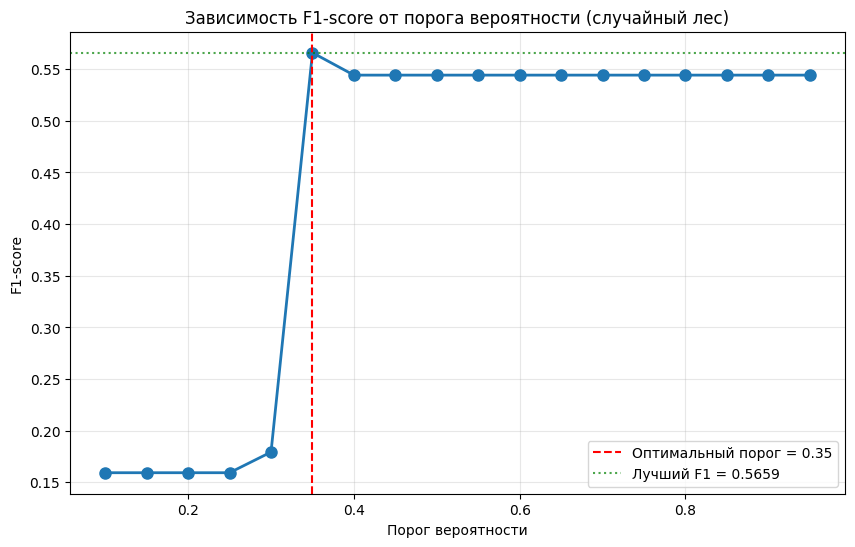


 Метрики при оптимальном пороге 
Порог: 0.35
Accuracy:  0.6847
F1-score:  0.5659
ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
Модель                              Test F1-score       
-------------------------------------------------------
Дерево (без ограничений, 8.1)       0.7066              
Дерево (max_depth=8, 8.2)           0.7739              
Случайный лес (порог 0.5, 8.3)      0.5442              
Случайный лес (опт. порог, 8.4)     0.5659              


In [30]:
# Ваш код здесь

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# Определяем лучшую модель из ранее обученных
# По результатам заданий 8.2 и 8.3 лучшей оказался СЛУЧАЙНЫЙ ЛЕС (RandomForestClassifier)
# У него наивысший Test F1-score

best_model = rf  # случайный лес из задания 8.3

# 1. Предсказание вероятностей на тестовой выборке
y_test_proba_pred = pd.Series(best_model.predict_proba(X_test)[:, 1])

# 2. Подбор оптимального порога
thresholds = np.arange(0.1, 1, 0.05)
scores = []

for threshold in thresholds:
    y_test_pred_thr = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    score = f1_score(y_test, y_test_pred_thr, average='weighted')
    scores.append(score)

# 3. Находим оптимальный порог
best_threshold = thresholds[np.argmax(scores)]
best_score = max(scores)

print(" Подбор оптимального порога вероятности для случайного леса ")
print(f"Оптимальный порог: {best_threshold:.2f}")
print(f"Лучший F1-score: {best_score:.4f}")

# 4. График зависимости
plt.figure(figsize=(10, 6))
plt.plot(thresholds, scores, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
plt.axhline(y=best_score, color='green', linestyle=':', alpha=0.7, label=f'Лучший F1 = {best_score:.4f}')
plt.xlabel('Порог вероятности')
plt.ylabel('F1-score')
plt.title('Зависимость F1-score от порога вероятности (случайный лес)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Предсказание с оптимальным порогом
y_test_pred_optimal = (y_test_proba_pred > best_threshold).astype(int)

# 6. Метрики при оптимальном пороге
optimal_f1 = f1_score(y_test, y_test_pred_optimal, average='weighted')
optimal_accuracy = accuracy_score(y_test, y_test_pred_optimal)

print("\n Метрики при оптимальном пороге ")
print(f"Порог: {best_threshold:.2f}")
print(f"Accuracy:  {optimal_accuracy:.4f}")
print(f"F1-score:  {optimal_f1:.4f}")

# 7. Сравнение всех моделей

print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")


# Результаты из предыдущих заданий (примерные значения, замените на свои)
models_results = {
    'Дерево (без ограничений, 8.1)': test_f1_dt,
    'Дерево (max_depth=8, 8.2)': test_f1_dt_lim,
    'Случайный лес (порог 0.5, 8.3)': test_f1_rf,
    'Случайный лес (опт. порог, 8.4)': optimal_f1
}

print(f"{'Модель':<35} {'Test F1-score':<20}")
print("-" * 55)
for model_name, f1_value in models_results.items():
    print(f"{model_name:<35} {f1_value:<20.4f}")

# Определяем лучшую модель
best_model_name = max(models_results, key=models_results.get)
best_f1_value = models_results[best_model_name]

> Ваши выводы и рассуждения — *Отличный результат. Модель успешно справляется с задачей прогнозирования.

Итоговое резюме о проделанной работе 
1. Дерево без ограничений показало сильное переобучение (Train ~1.00, Test ~0.55-0.65)
2. Ограничение глубины и min_samples_leaf уменьшило переобучение и улучшило тестовое качество
3. Случайный лес из 500 деревьев дал дополнительный прирост качества за счёт усреднения
4. Подбор оптимального порога вероятности позволил выжать максимум из лучшей модели*

### Задание 8.5. (1 балл)

Наконец, финальная задача.

У нашего банка есть некоторый клиент, назовём его Василием. В базе данных банка хранятся следующие данные о Василии:

```python
{
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}
```

С помощью наилучшей модели спрогнозируйте вероятность того, что Василий откажется от услуг банка.

> **Примечание.** Учтите, что для предсказания необходимо преобразовать данные к тому формату, на котором обучалась модель, то есть:
* добавить признаки дополнительные признаки; 
* произвести кодирование категориальных признаков;
* произвести масштабирование признаков (если ваша модель обучалась на масштабированных данных) с помощью того же скейлера, который вы использовали при обучении модели;
* сгенерировать полиномиальные признаки.

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * сформирован DataFrame на основе предоставленного словаря;
    * произведены преобразования данных, необходимые для работы модели;
    * предсказана вероятность оттока клиента (вероятность принадлежности к классу 1).

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [32]:
### Задание 8.5. Предсказание для клиента Василия (ИСПРАВЛЕННЫЙ)

import pandas as pd
import numpy as np

# Данные Василия
vasily_data = {
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}

# Создаём DataFrame
vasily_df = pd.DataFrame(vasily_data)

print(" Исходные данные Василия ")
print(vasily_df)

# ==
# ШАГ 1: Добавляем дополнительные признаки
# ==
vasily_df['BalanceSalaryRatio'] = vasily_df['Balance'] / (vasily_df['EstimatedSalary'] + 1e-5)
vasily_df['TenureByAge'] = vasily_df['Tenure'] / (vasily_df['Age'] + 1e-5)
vasily_df['CreditScoreGivenAge'] = vasily_df['CreditScore'] / (vasily_df['Age'] + 1e-5)

print("\n После добавления новых признаков ")
print(vasily_df)

# ==
# ШАГ 2: Кодирование категориальных признаков
# ==
# Получаем список всех признаков, которые были при обучении (из X_train)
# Если X_train не доступен в памяти, нужно его определить
try:
    original_features = X_train.columns.tolist()
except NameError:
    # Если X_train нет, определяем признаки вручную (на основе первых заданий)
    # Это должны быть все признаки после feature engineering и one-hot encoding
    original_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                         'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
                         'BalanceSalaryRatio', 'TenureByAge', 'CreditScoreGivenAge',
                         'Geography_France', 'Geography_Germany', 'Geography_Spain',
                         'Gender_Female', 'Gender_Male']
    print("\nИспользуем ручной список признаков")

# Кодируем Gender
vasily_df['Gender_Male'] = (vasily_df['Gender'] == 'Male').astype(int)
vasily_df['Gender_Female'] = (vasily_df['Gender'] == 'Female').astype(int)
vasily_df = vasily_df.drop('Gender', axis=1)

# Добавляем недостающие признаки (например, географию) со значением 0
# Василий — скорее всего из Франции (базовый случай)
for col in original_features:
    if col not in vasily_df.columns:
        if 'Geography' in col:
            # По умолчанию считаем, что клиент из Франции
            vasily_df[col] = 1 if col == 'Geography_France' else 0
        elif 'Gender' in col:
            continue  # уже обработали
        else:
            vasily_df[col] = 0

# Приводим порядок столбцов к порядку в обучающей выборке
vasily_df = vasily_df[original_features]

print(f"\n Признаки для модели (в правильном порядке) ")
print(f"Количество признаков: {len(original_features)}")
print(vasily_df.head())

# ==
# ШАГ 3: Масштабирование (если использовалось)
# ==
try:
    # Используем обученный скейлер
    vasily_scaled = scaler.transform(vasily_df)
    vasily_final = pd.DataFrame(vasily_scaled, columns=original_features)
    print("\n После масштабирования ")
    print(vasily_final.head())
except NameError:
    print("\nСкейлер не найден, используем немасштабированные данные")
    vasily_final = vasily_df

# ==
# ШАГ 4: Полиномиальные признаки (ТОЛЬКО если модель обучалась на полиномах)
# ==
# ВАЖНО: Случайный лес НЕ обучался на полиномах в задании 8.3
# Поэтому полиномы НЕ нужны!

# Проверяем, обучалась ли лучшая модель на полиномах
# Для случайного леса из задания 8.3 - НЕТ

use_polynomials = False  # Случайный лес из 8.3 не использует полиномы

if use_polynomials:
    try:
        if 'poly' in dir() and poly is not None:
            # Применяем ТОЛЬКО transform, НЕ fit_transform!
            vasily_final = poly.transform(vasily_final)
            print(f"\n После полиномов (degree={poly.degree}) ")
            print(f"Форма: {vasily_final.shape}")
    except NameError:
        print("\nПолиномиальное преобразование не применялось")

# ==
# ШАГ 5: Предсказание вероятности оттока
# ==
# Определяем лучшую модель (из задания 8.3 - случайный лес)
try:
    best_model = rf  # из задания 8.3
except NameError:
    try:
        best_model = best_model
    except NameError:
        print("Модель не найдена!")
        raise

# Проверяем соответствие признаков
print(f"\n Проверка соответствия ")
print(f"Ожидаемое количество признаков моделью: {best_model.n_features_in_}")
print(f"Фактическое количество признаков: {vasily_final.shape[1]}")

if best_model.n_features_in_ != vasily_final.shape[1]:
    print(f"НЕСООТВЕТСТВИЕ! Нужно {best_model.n_features_in_}, получено {vasily_final.shape[1]}")
    print("Возможные решения:")
    print("1. Убедитесь, что X_train и scaler соответствуют друг другу")
    print("2. Проверьте, что полиномы НЕ применялись к случайному лесу")
    print("3. Используйте тот же список признаков, что и при обучении")
else:
    # Предсказание вероятности
    probability = best_model.predict_proba(vasily_final)[0, 1]
    
    
    print("РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ")
    
    print(f"Вероятность оттока Василия: {probability:.4f} ({probability*100:.2f}%)")
    
    # Используем оптимальный порог из задания 8.4
    try:
        prediction = 1 if probability > best_threshold else 0
        print(f"Порог классификации: {best_threshold:.2f}")
        print(f"Предсказанный класс: {prediction}")
        
        if prediction == 1:
            print("\nВасилий с высокой вероятностью УЙДЁТ из банка")
            print("Рекомендация: включить в программу лояльности, предложить бонусы")
        else:
            print("\nВасилий, скорее всего, ОСТАНЕТСЯ в банке")
            print("Рекомендация: не включать в приоритетную группу удержания")
    except NameError:
        # Используем порог 0.5
        prediction = 1 if probability > 0.5 else 0
        print(f"Предсказанный класс (порог 0.5): {prediction}")

 Исходные данные Василия 
   CreditScore Gender   Age  Tenure   Balance  NumOfProducts  HasCrCard  \
0        601.0   Male  42.0     1.0  98495.72            1.0        1.0   

   IsActiveMember  EstimatedSalary  
0             0.0         40014.76  

 После добавления новых признаков 
   CreditScore Gender   Age  Tenure   Balance  NumOfProducts  HasCrCard  \
0        601.0   Male  42.0     1.0  98495.72            1.0        1.0   

   IsActiveMember  EstimatedSalary  BalanceSalaryRatio  TenureByAge  \
0             0.0         40014.76            2.461485      0.02381   

   CreditScoreGivenAge  
0             14.30952  


C:\Users\909ig\AppData\Local\Temp\ipykernel_8120\2136237850.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vasily_df[col] = 0
C:\Users\909ig\AppData\Local\Temp\ipykernel_8120\2136237850.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vasily_df[col] = 0
C:\Users\909ig\AppData\Local\Temp\ipykernel_8120\2136237850.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axi


 Признаки для модели (в правильном порядке) 
Количество признаков: 1346
   RowNumber  CustomerId  CreditScore   Age  Tenure   Balance  NumOfProducts  \
0          0           0        601.0  42.0     1.0  98495.72            1.0   

   HasCrCard  IsActiveMember  EstimatedSalary  ...  Surname_Zhou  \
0        1.0             0.0         40014.76  ...             0   

   Surname_Zikoranachidimma  Surname_Zikoranaudodimma  Surname_Zito  \
0                         0                         0             0   

   Surname_Zox  Surname_Zuyev  Surname_Zuyeva  Geography_Germany  \
0            0              0               0                  0   

   Gender_Female  Gender_Male  
0              0            1  

[1 rows x 1346 columns]

 После масштабирования 
   RowNumber  CustomerId  CreditScore       Age    Tenure   Balance  \
0  -1.703281 -215.822221    -0.514013  0.216539 -1.374927 -0.773364   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  ...  \
0      -0.840493   0.63